<a href="https://colab.research.google.com/github/mouni27-04/DSInternship/blob/main/DS_Internship.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd


In [2]:
# Load the datasets
fear_greed = pd.read_csv('fear_greed_index.csv')
trades = pd.read_csv('historical_data.csv')

In [3]:
print("=== Fear & Greed Dataset ===")
print("Shape:", fear_greed.shape)
print(fear_greed.dtypes)
print(fear_greed.head())

print("\n=== Trader Data ===")
print("Shape:", trades.shape)
print(trades.dtypes)
print(trades.head())

=== Fear & Greed Dataset ===
Shape: (2644, 4)
timestamp          int64
value              int64
classification    object
date              object
dtype: object
    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05

=== Trader Data ===
Shape: (211224, 16)
Account              object
Coin                 object
Execution Price     float64
Size Tokens         float64
Size USD            float64
Side                 object
Timestamp IST        object
Start Position      float64
Direction            object
Closed PnL          float64
Transaction Hash     object
Order ID              int64
Crossed                bool
Fee                 float64
Trade ID            float64
Timestamp           float64
dtype: object
                                      Account  Co

In [4]:
print("Missing values - Fear/Greed:\n", fear_greed.isnull().sum())
print("\nMissing values - Trades:\n", trades.isnull().sum())

Missing values - Fear/Greed:
 timestamp         0
value             0
classification    0
date              0
dtype: int64

Missing values - Trades:
 Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


In [5]:
print("Duplicate rows - Fear/Greed:", fear_greed.duplicated().sum())
print("Duplicate rows - Trades:", trades.duplicated().sum())

Duplicate rows - Fear/Greed: 0
Duplicate rows - Trades: 0


In [6]:
fear_greed['date'] = pd.to_datetime(fear_greed['date'])
fear_greed['date'] = fear_greed['date'].dt.date  # normalized daily date

In [7]:
print(fear_greed.head())

    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05


In [8]:
# Check the column name first — could be 'time', 'timestamp', etc.
print(trades['Timestamp'].head())

trades['datetime'] = pd.to_datetime(trades['Timestamp'], unit='ms')

trades['date'] = trades['datetime'].dt.date  # normalized daily date

0    1.730000e+12
1    1.730000e+12
2    1.730000e+12
3    1.730000e+12
4    1.730000e+12
Name: Timestamp, dtype: float64


In [9]:
# Use the correct column name
trades['datetime'] = pd.to_datetime(trades['Timestamp'], unit='ms')
trades['date'] = trades['datetime'].dt.date

In [10]:
print(trades.head())

                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
3       142.98   1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
4         8.73     69.75  BUY  02-12-2024 22:50     1289.488521       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \
0         0.0  0xec0945

In [11]:
print(trades[['Timestamp', 'datetime', 'date']].head())
# Filter out NaT values from the 'date' column before calculating min/max
valid_dates = trades['date'].dropna()
print("Date range:", valid_dates.min(), "to", valid_dates.max())

      Timestamp            datetime        date
0  1.730000e+12 2024-10-27 03:33:20  2024-10-27
1  1.730000e+12 2024-10-27 03:33:20  2024-10-27
2  1.730000e+12 2024-10-27 03:33:20  2024-10-27
3  1.730000e+12 2024-10-27 03:33:20  2024-10-27
4  1.730000e+12 2024-10-27 03:33:20  2024-10-27
Date range: 2023-03-28 to 2025-06-15


In [12]:
print(trades.columns.tolist())

['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp', 'datetime', 'date']


In [13]:
print(trades['Side'].unique())
print(trades['Direction'].unique())

['BUY' 'SELL']
['Buy' 'Sell' 'Open Long' 'Close Long' 'Spot Dust Conversion' 'Open Short'
 'Close Short' 'Long > Short' 'Short > Long' 'Auto-Deleveraging'
 'Liquidated Isolated Short' 'Settlement']


In [14]:
def classify_direction(d):
    if pd.isna(d):  # Handle NaN values
        return 'Other'
    if 'Long' in d and d != 'Long > Short':
        return 'Long'
    elif 'Short' in d and d != 'Short > Long':
        return 'Short'
    elif d in ['Long > Short', 'Short > Long']:
        return 'Flip'  # position reversal, worth tracking separately
    else:
        return 'Other'  # Buy, Sell, Spot Dust Conversion, Auto-Deleveraging, Settlement

trades['position_type'] = trades['Direction'].apply(classify_direction)
print(trades['position_type'].value_counts())

position_type
Long     98643
Short    75812
Other    36769
Name: count, dtype: int64


In [15]:
trades['is_open'] = trades['Direction'].str.contains('Open')
trades['is_close'] = trades['Direction'].str.contains('Close')

In [16]:
trades['is_liquidated'] = trades['Direction'].str.contains('Liquidated')
print("Liquidation events:", trades['is_liquidated'].sum())

Liquidation events: 1


In [17]:
daily_trader = trades.groupby(['Account', 'date']).agg(
    daily_pnl=('Closed PnL', 'sum'),
    num_trades=('Closed PnL', 'count'),
    avg_trade_size=('Size USD', 'mean'),
    win_rate=('Closed PnL', lambda x: (x > 0).mean()),
    long_trades=('position_type', lambda x: (x == 'Long').sum()),
    short_trades=('position_type', lambda x: (x == 'Short').sum()),
    liquidation_count=('is_liquidated', 'sum')
).reset_index()

daily_trader['long_short_ratio'] = daily_trader['long_trades'] / daily_trader['short_trades'].replace(0, 1)

In [18]:
print(trades[['Size USD', 'Start Position']].head(10))

   Size USD  Start Position
0   7872.16        0.000000
1    127.68      986.524596
2   1150.63     1002.518996
3   1142.04     1146.558564
4     69.75     1289.488521
5     11.27     1298.215466
6   1151.77     1299.624972
7    272.00     1443.664541
8    368.00     1477.652641
9    100.00     1523.636541


In [19]:
# No reliable leverage column available — document as a limitation
print("Leverage not directly available in this dataset; Start Position appears to be "
      "token quantity, not margin, so Size USD / Start Position is not a valid leverage proxy.")

Leverage not directly available in this dataset; Start Position appears to be token quantity, not margin, so Size USD / Start Position is not a valid leverage proxy.


In [20]:
daily_trader = trades.groupby(['Account', 'date']).agg(
    daily_pnl=('Closed PnL', 'sum'),
    num_trades=('Closed PnL', 'count'),
    avg_trade_size=('Size USD', 'mean'),
    win_rate=('Closed PnL', lambda x: (x > 0).mean()),
    long_trades=('position_type', lambda x: (x == 'Long').sum()),
    short_trades=('position_type', lambda x: (x == 'Short').sum()),
    liquidation_count=('is_liquidated', 'sum')
).reset_index()

daily_trader['long_short_ratio'] = daily_trader['long_trades'] / daily_trader['short_trades'].replace(0, 1)

print(daily_trader.shape)
print(daily_trader.head())

(102, 10)
                                      Account        date     daily_pnl  \
0  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-10-27 -3.275059e+05   
1  0x083384f897ee0f19899168e3b1bec365f52a9012  2025-02-19  1.927736e+06   
2  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd  2024-10-27  2.060745e+04   
3  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd  2025-02-19  1.709873e+04   
4  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd  2025-06-15  1.017915e+04   

   num_trades  avg_trade_size  win_rate  long_trades  short_trades  \
0         462    14810.891818  0.025974            0           462   
1        3356    16345.241940  0.405542          570          2786   
2         320     2492.749906  0.531250           34             0   
3        3533     1693.351684  0.435041          340           464   
4        3427     1533.468395  0.442369         1071           678   

   liquidation_count  long_short_ratio  
0                  0          0.000000  
1                  0          0.2045

In [21]:
merged = daily_trader.merge(
    fear_greed[['date', 'classification']],
    on='date',
    how='left'
)
merged.rename(columns={'classification': 'sentiment'}, inplace=True)

print("Merged shape:", merged.shape)
print("Missing sentiment after merge:", merged['sentiment'].isnull().sum())
print(merged['sentiment'].value_counts())
print(merged.head())

Merged shape: (102, 11)
Missing sentiment after merge: 25
sentiment
Greed            32
Fear             32
Neutral           8
Extreme Greed     5
Name: count, dtype: int64
                                      Account        date     daily_pnl  \
0  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-10-27 -3.275059e+05   
1  0x083384f897ee0f19899168e3b1bec365f52a9012  2025-02-19  1.927736e+06   
2  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd  2024-10-27  2.060745e+04   
3  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd  2025-02-19  1.709873e+04   
4  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd  2025-06-15  1.017915e+04   

   num_trades  avg_trade_size  win_rate  long_trades  short_trades  \
0         462    14810.891818  0.025974            0           462   
1        3356    16345.241940  0.405542          570          2786   
2         320     2492.749906  0.531250           34             0   
3        3533     1693.351684  0.435041          340           464   
4        3427     1533.46

In [22]:
print("Trader data date range:", daily_trader['date'].min(), "to", daily_trader['date'].max())
print("Fear/Greed data date range:", fear_greed['date'].min(), "to", fear_greed['date'].max())

# Which specific dates are missing sentiment?
missing_dates = merged[merged['sentiment'].isnull()]['date'].unique()
print("Dates with no sentiment match:", sorted(missing_dates))

Trader data date range: 2023-03-28 to 2025-06-15
Fear/Greed data date range: 2018-02-01 to 2025-05-02
Dates with no sentiment match: [datetime.date(2025, 6, 15)]


In [23]:
merged_clean = merged.dropna(subset=['sentiment'])
print("Rows usable for sentiment analysis:", merged_clean.shape[0])
print(merged_clean['sentiment'].value_counts())

Rows usable for sentiment analysis: 77
sentiment
Greed            32
Fear             32
Neutral           8
Extreme Greed     5
Name: count, dtype: int64


In [24]:
def simplify_sentiment(s):
    if 'Greed' in s:
        return 'Greed'
    elif 'Fear' in s:
        return 'Fear'
    else:
        return 'Neutral'

merged_clean['sentiment_group'] = merged_clean['sentiment'].apply(simplify_sentiment)
print(merged_clean['sentiment_group'].value_counts())

sentiment_group
Greed      37
Fear       32
Neutral     8
Name: count, dtype: int64


/tmp/ipykernel_8122/2573689489.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_clean['sentiment_group'] = merged_clean['sentiment'].apply(simplify_sentiment)


In [25]:
merged_clean = merged.dropna(subset=['sentiment']).copy()

def simplify_sentiment(s):
    if 'Greed' in s:
        return 'Greed'
    elif 'Fear' in s:
        return 'Fear'
    else:
        return 'Neutral'

merged_clean['sentiment_group'] = merged_clean['sentiment'].apply(simplify_sentiment)
print(merged_clean['sentiment_group'].value_counts())

sentiment_group
Greed      37
Fear       32
Neutral     8
Name: count, dtype: int64


In [26]:
summary = merged_clean.groupby('sentiment_group').agg(
    avg_daily_pnl=('daily_pnl', 'mean'),
    median_daily_pnl=('daily_pnl', 'median'),
    avg_win_rate=('win_rate', 'mean'),
    total_trades=('num_trades', 'sum'),
    avg_trades_per_day=('num_trades', 'mean'),
    avg_trade_size=('avg_trade_size', 'mean'),
    avg_long_short_ratio=('long_short_ratio', 'mean'),
    total_liquidations=('liquidation_count', 'sum'),
    num_trader_days=('Account', 'count')
).round(2)

print(summary)

                 avg_daily_pnl  median_daily_pnl  avg_win_rate  total_trades  \
sentiment_group                                                                
Fear                 209372.66          81389.68          0.42        133871   
Greed                 90988.70          20925.51          0.37         43251   
Neutral               19842.80             -0.42          0.26          7141   

                 avg_trades_per_day  avg_trade_size  avg_long_short_ratio  \
sentiment_group                                                             
Fear                        4183.47         5926.52                720.61   
Greed                       1168.95         5637.30                153.71   
Neutral                      892.62         3793.44                 31.99   

                 total_liquidations  num_trader_days  
sentiment_group                                       
Fear                              0               32  
Greed                             0             

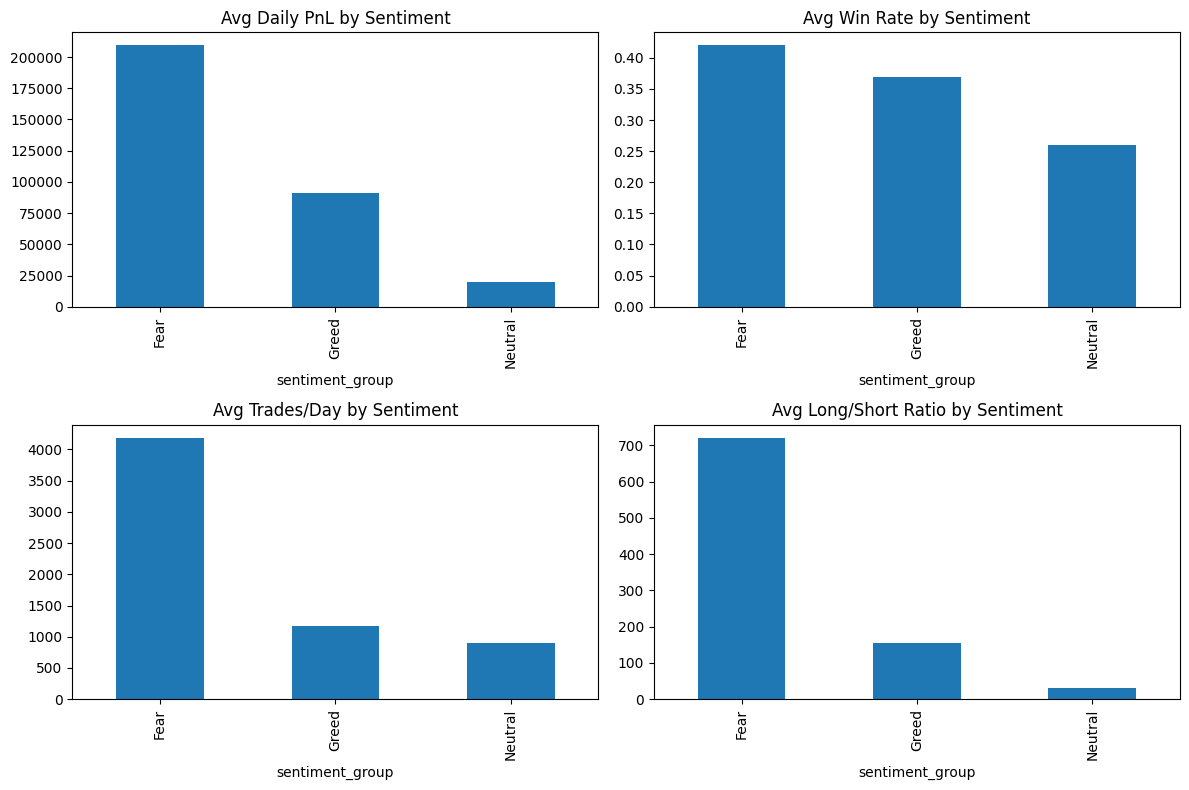

In [27]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

summary['avg_daily_pnl'].plot(kind='bar', ax=axes[0,0], title='Avg Daily PnL by Sentiment')
summary['avg_win_rate'].plot(kind='bar', ax=axes[0,1], title='Avg Win Rate by Sentiment')
summary['avg_trades_per_day'].plot(kind='bar', ax=axes[1,0], title='Avg Trades/Day by Sentiment')
summary['avg_long_short_ratio'].plot(kind='bar', ax=axes[1,1], title='Avg Long/Short Ratio by Sentiment')

plt.tight_layout()
plt.savefig('sentiment_comparison.png', dpi=150)
plt.show()

In [28]:
print(trades['Direction'].str.contains('Liquidat', na=False).sum())
print(trades[trades['Direction'].str.contains('Liquidat', na=False)]['Direction'].unique())

1
['Liquidated Isolated Short']


In [29]:
print(merged_clean.groupby('sentiment_group')['daily_pnl'].describe())

                 count           mean            std            min  \
sentiment_group                                                       
Fear              32.0  209372.662205  380423.906864  -59349.677108   
Greed             37.0   90988.703436  264805.415699 -327505.900056   
Neutral            8.0   19842.797260   57227.787895  -25991.506339   

                          25%           50%            75%           max  
sentiment_group                                                           
Fear             21140.798004  81389.682515  203219.937358  1.927736e+06  
Greed               55.015240  20925.513222   67900.247545  1.421756e+06  
Neutral         -10470.244431     -0.418640   15808.361499  1.455634e+05  


In [30]:
top_pnl_days = merged_clean.sort_values('daily_pnl', ascending=False).head(5)
print(top_pnl_days[['Account', 'date', 'sentiment_group', 'daily_pnl', 'num_trades']])

                                       Account        date sentiment_group  \
1   0x083384f897ee0f19899168e3b1bec365f52a9012  2025-02-19            Fear   
90  0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23  2024-10-27           Greed   
94  0xbaaaf6571ab7d571043ff1e313a9609a10637864  2025-02-19            Fear   
99  0xbee1707d6b44d4d52bfe19e41f8a828645437aab  2024-10-27           Greed   
37  0x4acb90e786d897ecffb614dc822eb231b4ffb9f4  2025-02-19            Fear   

       daily_pnl  num_trades  
1   1.927736e+06        3356  
90  1.421756e+06        1268  
94  9.401572e+05       21190  
99  6.842150e+05        9883  
37  6.133278e+05        3806  


In [31]:
print(trades['Direction'].str.contains('Liquidat').sum())
print(trades[trades['Direction'].str.contains('Liquidat')]['Direction'].unique())

1
['Liquidated Isolated Short']


In [32]:
# What did Bitcoin/sentiment look like on these specific dates?
print(fear_greed[fear_greed['date'].isin([pd.to_datetime('2024-10-27').date(), pd.to_datetime('2025-02-19').date()])])

# How many accounts were active on these two dates?
print(merged_clean[merged_clean['date'].isin([pd.to_datetime('2024-10-27').date(), pd.to_datetime('2025-02-19').date()])].groupby('date')['Account'].count())

       timestamp  value classification        date
2456  1730007000     74          Greed  2024-10-27
2571  1739943000     44           Fear  2025-02-19
date
2024-10-27    29
2025-02-19    32
Name: Account, dtype: int64


In [33]:
# Find the liquidation row
liq_row = trades[trades['Direction'].str.contains('Liquidat')]
print(liq_row[['Account', 'date', 'Direction']])

# Check if that specific date/account combo made it into merged_clean
liq_date = liq_row['date'].values[0]
liq_account = liq_row['Account'].values[0]
print(merged_clean[(merged_clean['Account'] == liq_account) & (merged_clean['date'] == liq_date)])

                                           Account        date  \
118646  0x8170715b3b381dffb7062c0298972d4727a0a63b  2025-06-15   

                        Direction  
118646  Liquidated Isolated Short  
Empty DataFrame
Columns: [Account, date, daily_pnl, num_trades, avg_trade_size, win_rate, long_trades, short_trades, liquidation_count, long_short_ratio, sentiment, sentiment_group]
Index: []


In [34]:
# Total trades per account (across all days)
account_activity = merged_clean.groupby('Account')['num_trades'].sum().reset_index()
median_activity = account_activity['num_trades'].median()

account_activity['activity_segment'] = account_activity['num_trades'].apply(
    lambda x: 'Frequent' if x >= median_activity else 'Infrequent'
)

merged_clean = merged_clean.merge(account_activity[['Account', 'activity_segment']], on='Account', how='left')
print(merged_clean['activity_segment'].value_counts())

activity_segment
Infrequent    39
Frequent      38
Name: count, dtype: int64


In [35]:
account_consistency = merged_clean.groupby('Account')['win_rate'].agg(['mean', 'std']).reset_index()
account_consistency.columns = ['Account', 'avg_win_rate', 'win_rate_std']

median_win_rate = account_consistency['avg_win_rate'].median()
account_consistency['performance_segment'] = account_consistency['avg_win_rate'].apply(
    lambda x: 'Consistent Winner' if x >= median_win_rate else 'Inconsistent'
)

merged_clean = merged_clean.merge(account_consistency[['Account', 'performance_segment']], on='Account', how='left')
print(merged_clean['performance_segment'].value_counts())

performance_segment
Inconsistent         43
Consistent Winner    34
Name: count, dtype: int64


In [36]:
segment_summary = merged_clean.groupby(['activity_segment', 'sentiment_group']).agg(
    avg_daily_pnl=('daily_pnl', 'median'),  # using median given the outlier skew we found
    avg_win_rate=('win_rate', 'mean'),
    avg_trades=('num_trades', 'mean'),
    count=('Account', 'count')
).round(2)

print(segment_summary)

                                  avg_daily_pnl  avg_win_rate  avg_trades  \
activity_segment sentiment_group                                            
Frequent         Fear                 121690.12          0.43     7335.50   
                 Greed                 44579.55          0.41     2233.22   
                 Neutral               -4562.50          0.26     1692.00   
Infrequent       Fear                  55196.90          0.40     1031.44   
                 Greed                  8695.36          0.33      160.68   
                 Neutral                 107.38          0.26       93.25   

                                  count  
activity_segment sentiment_group         
Frequent         Fear                16  
                 Greed               18  
                 Neutral              4  
Infrequent       Fear                16  
                 Greed               19  
                 Neutral              4  


In [37]:
perf_summary = merged_clean.groupby(['performance_segment', 'sentiment_group']).agg(
    avg_daily_pnl=('daily_pnl', 'median'),
    avg_win_rate=('win_rate', 'mean'),
    avg_trades=('num_trades', 'mean'),
    count=('Account', 'count')
).round(2)

print(perf_summary)

                                     avg_daily_pnl  avg_win_rate  avg_trades  \
performance_segment sentiment_group                                            
Consistent Winner   Fear                  34186.06          0.48     5110.00   
                    Greed                 61076.17          0.57     1547.60   
                    Neutral                   0.16          0.37       98.00   
Inconsistent        Fear                 141952.72          0.35     3256.94   
                    Greed                  2200.03          0.23      910.77   
                    Neutral                  -1.00          0.19     1369.40   

                                     count  
performance_segment sentiment_group         
Consistent Winner   Fear                16  
                    Greed               15  
                    Neutral              3  
Inconsistent        Fear                16  
                    Greed               22  
                    Neutral              5  

In [38]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Build per-account feature set (aggregate across all days)
account_features = merged_clean.groupby('Account').agg(
    total_pnl=('daily_pnl', 'sum'),
    avg_win_rate=('win_rate', 'mean'),
    avg_trades_per_day=('num_trades', 'mean'),
    avg_trade_size=('avg_trade_size', 'mean'),
    avg_long_short_ratio=('long_short_ratio', 'mean')
).reset_index()

# Scale features
features = ['avg_win_rate', 'avg_trades_per_day', 'avg_trade_size', 'avg_long_short_ratio']
X = StandardScaler().fit_transform(account_features[features])

# Cluster into 3-4 archetypes
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
account_features['cluster'] = kmeans.fit_predict(X)

print(account_features.groupby('cluster')[features + ['total_pnl']].mean().round(2))
print(account_features['cluster'].value_counts())

         avg_win_rate  avg_trades_per_day  avg_trade_size  \
cluster                                                     
0                0.26             1516.11         8719.29   
1                0.47            21190.00         3210.78   
2                0.47             3087.00         3293.81   

         avg_long_short_ratio  total_pnl  
cluster                                   
0                       16.07  406755.24  
1                    21187.00  940157.21  
2                      211.73  211207.00  
cluster
2    17
0    14
1     1
Name: count, dtype: int64


In [39]:
print(account_features[account_features['cluster'] == 1])

                                       Account      total_pnl  avg_win_rate  \
29  0xbaaaf6571ab7d571043ff1e313a9609a10637864  940157.212682      0.467532   

    avg_trades_per_day  avg_trade_size  avg_long_short_ratio  cluster  
29             21190.0     3210.775186               21187.0        1  


In [40]:
import os
os.makedirs('outputs', exist_ok=True)
summary.to_csv('outputs/sentiment_summary.csv')
segment_summary.to_csv('outputs/activity_segment_summary.csv')
perf_summary.to_csv('outputs/performance_segment_summary.csv')
account_features.to_csv('outputs/cluster_features.csv')

In [41]:
outlier = account_features[account_features['cluster'] == 1]
print(outlier)

                                       Account      total_pnl  avg_win_rate  \
29  0xbaaaf6571ab7d571043ff1e313a9609a10637864  940157.212682      0.467532   

    avg_trades_per_day  avg_trade_size  avg_long_short_ratio  cluster  
29             21190.0     3210.775186               21187.0        1  


In [42]:
acct_id = outlier['Account'].values[0]
acct_trades = trades[trades['Account'] == acct_id]
print(acct_trades.shape)
print(acct_trades[['date', 'Closed PnL', 'Size USD', 'Direction']].describe(include='all'))

(21192, 22)
              date    Closed PnL      Size USD  Direction
count        21192  21192.000000  2.119200e+04      21192
unique           2           NaN           NaN          4
top     2025-02-19           NaN           NaN  Open Long
freq         21190           NaN           NaN      11194
mean           NaN     44.364091  3.210473e+03        NaN
std            NaN    567.762763  1.386543e+04        NaN
min            NaN     -5.444032  1.200000e-01        NaN
25%            NaN      0.000000  1.659825e+02        NaN
50%            NaN      0.000000  5.953150e+02        NaN
75%            NaN      5.554737  2.063950e+03        NaN
max            NaN  68959.002120  1.120972e+06        NaN


In [43]:
per_day = acct_trades.groupby('date').size()
print(per_day.describe())
print(per_day.sort_values(ascending=False).head(10))

count        2.00000
mean     10596.00000
std      14982.17848
min          2.00000
25%       5299.00000
50%      10596.00000
75%      15893.00000
max      21190.00000
dtype: float64
date
2025-02-19    21190
2025-06-15        2
dtype: int64


In [44]:
print(acct_trades['Size USD'].describe())
print(acct_trades['Closed PnL'].describe())

count    2.119200e+04
mean     3.210473e+03
std      1.386543e+04
min      1.200000e-01
25%      1.659825e+02
50%      5.953150e+02
75%      2.063950e+03
max      1.120972e+06
Name: Size USD, dtype: float64
count    21192.000000
mean        44.364091
std        567.762763
min         -5.444032
25%          0.000000
50%          0.000000
75%          5.554737
max      68959.002120
Name: Closed PnL, dtype: float64


In [45]:
account_features_clean = account_features[account_features['Account'] != '0xbaaaf6571ab7d571043ff1e313a9609a10637864']

X = StandardScaler().fit_transform(account_features_clean[features])
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
account_features_clean['cluster'] = kmeans.fit_predict(X)

print(account_features_clean.groupby('cluster')[features + ['total_pnl']].mean().round(2))
print(account_features_clean['cluster'].value_counts())

         avg_win_rate  avg_trades_per_day  avg_trade_size  \
cluster                                                     
0                0.48             3011.29         2826.21   
1                0.28             1452.84         8951.64   
2                0.37             6742.50         1397.01   

         avg_long_short_ratio  total_pnl  
cluster                                   
0                       99.02  205013.89  
1                       15.03  408025.90  
2                     2113.63   89495.52  
cluster
1    15
0    15
2     1
Name: count, dtype: int64


/tmp/ipykernel_8122/1719187338.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  account_features_clean['cluster'] = kmeans.fit_predict(X)


In [46]:
account_features_clean = account_features[
    account_features['Account'] != '0xbaaaf6571ab7d571043ff1e313a9609a10637864'
].copy()

In [47]:
outlier2 = account_features_clean[account_features_clean['cluster'] == 2]
print(outlier2)

acct_id2 = outlier2['Account'].values[0]
acct_trades2 = trades[trades['Account'] == acct_id2]
print(acct_trades2.shape)
print(acct_trades2.groupby('date').size().sort_values(ascending=False).head(10))
print(acct_trades2[['Closed PnL', 'Size USD']].describe())

                                       Account      total_pnl  avg_win_rate  \
1   0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd   37706.173148      0.483146   
3   0x28736f43f1e871e6aa8b1148d38d4994275d72c4  132315.481685      0.438246   
4   0x2c229d22b100a7beb69122eed721cee9b24011dd  168627.984054      0.504117   
6   0x39cef799f8b69da1995852eea189df24eb5cae3c   14456.919336      0.423541   
7   0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6   53496.247243      0.486948   
9   0x430f09841d65beb3f27765503d0f850b8bce7713  416541.872341      0.579597   
10  0x47add9a56df66b524d5e2c1993a43cde53b6ed85  101965.643134      0.351853   
11  0x4acb90e786d897ecffb614dc822eb231b4ffb9f4  674403.995032      0.453428   
14  0x6d6a4b953f202f8df5bed40692e7fd865318264a  108518.614902      0.634615   
15  0x72743ae2822edd658c0c50608fd7c5c501b2afbd  425815.195065      0.477383   
17  0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4  361576.622700      0.652543   
18  0x7f4f299f74eec87806a830e3caa9afa5f2b9db8f   147

In [48]:
acct_id2 = '0xa0feb3725a9335f49874d7cd8eaad6be45b27416'
acct_trades2 = trades[trades['Account'] == acct_id2]
print(acct_trades2.shape)
print(acct_trades2.groupby('date').size().sort_values(ascending=False).head(10))
print(acct_trades2[['Closed PnL', 'Size USD']].describe())

(15605, 22)
date
2025-02-19    9274
2024-10-27    4211
2025-06-15    2120
dtype: int64
         Closed PnL       Size USD
count  15605.000000   15605.000000
mean       6.812104    1273.195000
std       68.234904    4847.366329
min    -7104.920076       0.060000
25%        0.000000     196.280000
50%        0.000000     536.700000
75%        1.260000    1174.540000
max     2148.534516  414876.880000


In [49]:
sizes = account_features_clean['cluster'].value_counts()
singleton_clusters = sizes[sizes == 1].index
print(account_features_clean[account_features_clean['cluster'].isin(singleton_clusters)])

Empty DataFrame
Columns: [Account, total_pnl, avg_win_rate, avg_trades_per_day, avg_trade_size, avg_long_short_ratio, cluster]
Index: []


In [50]:
print(account_features_clean.groupby('cluster')[features + ['total_pnl']].mean().round(2))
print(account_features_clean['cluster'].value_counts())

         avg_win_rate  avg_trades_per_day  avg_trade_size  \
cluster                                                     
0                0.26             1516.11         8719.29   
2                0.47             3087.00         3293.81   

         avg_long_short_ratio  total_pnl  
cluster                                   
0                       16.07  406755.24  
2                      211.73  211207.00  
cluster
2    17
0    14
Name: count, dtype: int64


In [51]:
print(account_features_clean.groupby('cluster')[features + ['total_pnl']].mean().round(2))
print(account_features_clean['cluster'].value_counts())

         avg_win_rate  avg_trades_per_day  avg_trade_size  \
cluster                                                     
0                0.26             1516.11         8719.29   
2                0.47             3087.00         3293.81   

         avg_long_short_ratio  total_pnl  
cluster                                   
0                       16.07  406755.24  
2                      211.73  211207.00  
cluster
2    17
0    14
Name: count, dtype: int64


In [52]:
# Sort by account and date first
merged_clean = merged_clean.sort_values(['Account', 'date'])

# Create next-day PnL per account
merged_clean['next_day_pnl'] = merged_clean.groupby('Account')['daily_pnl'].shift(-1)

# Binary target: was next day profitable?
merged_clean['next_day_profitable'] = (merged_clean['next_day_pnl'] > 0).astype(int)

# Drop rows where there's no next day (last day per account)
model_df = merged_clean.dropna(subset=['next_day_pnl']).copy()
print(model_df.shape)
print(model_df['next_day_profitable'].value_counts())

(45, 16)
next_day_profitable
1    40
0     5
Name: count, dtype: int64


In [53]:
feature_cols = ['daily_pnl', 'num_trades', 'avg_trade_size', 'win_rate', 'long_short_ratio']

# One-hot encode sentiment
model_df = pd.get_dummies(model_df, columns=['sentiment_group'], drop_first=True)
sentiment_cols = [c for c in model_df.columns if c.startswith('sentiment_group_')]

X = model_df[feature_cols + sentiment_cols]
y = model_df['next_day_profitable']

print(X.shape, y.shape)
print(X.head())

(45, 6) (45,)
       daily_pnl  num_trades  avg_trade_size  win_rate  long_short_ratio  \
0 -327505.900056         462    14810.891818  0.025974          0.000000   
2   20607.446093         320     2492.749906  0.531250         34.000000   
4      -1.000000           5     6070.200000  0.000000          0.000000   
5    1793.160215           5    31941.660000  0.800000          0.000000   
7  121880.386016        6472      483.590114  0.443758          0.941528   

   sentiment_group_Neutral  
0                    False  
2                    False  
4                     True  
5                    False  
7                    False  


In [54]:
print(model_df.filter(like='sentiment_group').columns.tolist())

['sentiment_group_Neutral']


In [55]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Stratified split to preserve class ratio in both train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

model = LogisticRegression(class_weight='balanced', max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Baseline (always predict majority class):", max(y.mean(), 1 - y.mean()))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Baseline (always predict majority class): 0.8888888888888888

Classification Report:
               precision    recall  f1-score   support

           0       0.20      1.00      0.33         2
           1       1.00      0.33      0.50        12

    accuracy                           0.43        14
   macro avg       0.60      0.67      0.42        14
weighted avg       0.89      0.43      0.48        14


Confusion Matrix:
 [[2 0]
 [8 4]]


In [56]:
print(merged_clean.loc[merged_clean.index.isin(model_df.index), 'sentiment_group'].value_counts())

sentiment_group
Greed      37
Neutral     8
Name: count, dtype: int64


In [57]:
import os
os.makedirs('outputs', exist_ok=True)
